# Training with BI-LSTM Model Demo

## Setup

In [ ]:
!pip install torch pandas myanmartools mmdt_tokenizer

In [ ]:
import re
import os

import numpy as np
import pandas as pd
from collections import Counter
import random

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt

from google.colab import drive
from google.colab import auth
from google.auth import default
from google.colab import files
import gspread

## Setting Random Seed for Reproducibility

In [ ]:
SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
generator = torch.Generator().manual_seed(SEED)

## Loading Dataset

In [ ]:
# mount drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# base folder to search from
base = '/content/drive/MyDrive'

# name of the shared folder
target_folder_name = 'AI - Week 1 - Group 2 - NLP Project'

# search recursively for it
shared_folder_path = None
for root, dirs, FILES in os.walk(base):
    if target_folder_name in dirs:
        shared_folder_path = os.path.join(root, target_folder_name)
        break

if shared_folder_path is None:
    raise FileNotFoundError(f"Could not find folder '{target_folder_name}' in MyDrive")

print("Found shared folder at:", shared_folder_path)

FileNotFoundError: Could not find folder 'AI - Week 1 - Group 2 - NLP Project' in MyDrive

In [ ]:
# point to data
data_folder = os.path.join(shared_folder_path, 'data/raw_data')

# authenticate to Google Sheets
auth.authenticate_user()
creds, _ = default()
gc = gspread.authorize(creds)

# open the spreadsheet file by its name
spreadsheet = gc.open('Combined') ## DATASET FILE NAME

# gets the first sheet
worksheet = spreadsheet.get_worksheet(0)

# convert to Pandas DataFrame
df = pd.DataFrame(worksheet.get_all_records())

In [107]:
df = pd.read_csv("/content/data_before_downsampling.csv")

df.head()

,text,label
0,ကမ်းလှမ်းချက်ကို ဝမ်းမြောက်ဝမ်းသာ လက်ခံပါတယ်,1
1,အဆင်ပြေအေးချမ်းပါစေ,2
2,သူမ ကြောက်လွန်းလို့ ဒူးတွေတုန်နေတယ်,4
3,အရမ်းကျေနပ်ပါတယ်ဗျ,1
4,ဖြစ်လိုရာဖြစ်ပါစေကွယ်,2


In [108]:
# ensure columns exist
TEXT_COL = "text"
LABEL_COL = "label"
if TEXT_COL not in df.columns or LABEL_COL not in df.columns:
  raise ValueError(
    f"expected CSV columns '{TEXT_COL}' and '{LABEL_COL}', got: {list(df.columns)}"
  )
else:
  print("Columns checked!")

Columns checked!


## Module: Zawgyi to Unicode

In [109]:
class Rabbit:
    @staticmethod
    def uni2zg(text):
        rules = [
            { "from": u"\u1004\u103a\u1039", "to": u"\u1064" }, { "from": u"\u1039\u1010\u103d", "to": u"\u1096" }, { "from": u"\u1014(?=[\u1030\u103d\u103e\u102f\u1039])", "to": u"\u108f" }, { "from": u"\u102b\u103a", "to": u"\u105a" }, { "from": u"\u100b\u1039\u100c", "to": u"\u1092" }, { "from": u"\u102d\u1036", "to": u"\u108e" }, { "from": u"\u104e\u1004\u103a\u1038", "to": u"\u104e" }, { "from": u"[\u1025\u1009](?=[\u1039\u102f\u1030])", "to": u"\u106a" }, { "from": u"[\u1025\u1009](?=[\u103a])", "to": u"\u1025" }, { "from": u"\u100a(?=[\u1039\u102f\u1030\u103d])", "to": u"\u106b" }, { "from": u"(\u1039[\u1000-\u1021])\u102f", "to": u"\\1\u1033" }, { "from": u"(\u1039[\u1000-\u1021])\u1030", "to": u"\\1\u1034" }, { "from": u"\u1039\u1000", "to": u"\u1060" }, { "from": u"\u1039\u1001", "to": u"\u1061" }, { "from": u"\u1039\u1002", "to": u"\u1062" }, { "from": u"\u1039\u1003", "to": u"\u1063" }, { "from": u"\u1039\u1005", "to": u"\u1065" }, { "from": u"\u1039\u1007", "to": u"\u1068" }, { "from": u"\u1039\u1008", "to": u"\u1069" }, { "from": u"\u100a(?=[\u1039\u102f\u1030])", "to": u"\u106b" }, { "from": u"\u1039\u100b", "to": u"\u106c" }, { "from": u"\u1039\u100c", "to": u"\u106d" }, { "from": u"\u100d\u1039\u100d", "to": u"\u106e" }, { "from": u"\u100e\u1039\u100d", "to": u"\u106f" }, { "from": u"\u1039\u100f", "to": u"\u1070" }, { "from": u"\u1039\u1010", "to": u"\u1071" }, { "from": u"\u1039\u1011", "to": u"\u1073" }, { "from": u"\u1039\u1012", "to": u"\u1075" }, { "from": u"\u1039\u1013", "to": u"\u1076" }, { "from": u"\u1039\u1013", "to": u"\u1076" }, { "from": u"\u1039\u1014", "to": u"\u1077" }, { "from": u"\u1039\u1015", "to": u"\u1078" }, { "from": u"\u1039\u1016", "to": u"\u1079" }, { "from": u"\u1039\u1017", "to": u"\u107a" }, { "from": u"\u1039\u1018", "to": u"\u107b" }, { "from": u"\u1039\u1019", "to": u"\u107c" }, { "from": u"\u1039\u101c", "to": u"\u1085" }, { "from": u"\u103f", "to": u"\u1086" }, { "from": u"(\u103c)\u103e", "to": u"\\1\u1087" }, { "from": u"\u103d\u103e", "to": u"\u108a" }, { "from": u"(\u1064)([\u1031]?)([\u103c]?)([\u1000-\u1021])\u102d", "to": u"\\2\\3\\4\u108b" }, { "from": u"(\u1064)([\u1031]?)([\u103c]?)([\u1000-\u1021])\u102e", "to": u"\\2\\3\\4\u108c" }, { "from": u"(\u1064)([\u1031]?)([\u103c]?)([\u1000-\u1021])\u1036", "to": u"\\2\\3\\4\u108d" }, { "from": u"(\u1064)([\u1031]?)([\u103c]?)([\u1000-\u1021])", "to": u"\\2\\3\\4\\1" }, { "from": u"\u101b(?=[\u102f\u1030\u103d\u108a])", "to": u"\u1090" }, { "from": u"\u100f\u1039\u100d", "to": u"\u1091" }, { "from": u"\u100b\u1039\u100b", "to": u"\u1097" }, { "from": u"([\u1000-\u1021\u1029\u1090])([\u1060-\u1069\u106c\u106d\u1070-\u107c\u1085\u108a])?([\u103b-\u103e]*)?\u1031", "to": u"\u1031\\1\\2\\3" }, { "from": u"([\u1000-\u1021\u1029])([\u1060-\u1069\u106c\u106d\u1070-\u107c\u1085])?(\u103c)", "to": u"\\3\\1\\2" }, { "from": u"\u103a", "to": u"\u1039" }, { "from": u"\u103b", "to": u"\u103a" }, { "from": u"\u103c", "to": u"\u103b" }, { "from": u"\u103d", "to": u"\u103c" }, { "from": u"\u103e", "to": u"\u103d" }, { "from": u"\u103d\u102f", "to": u"\u1088" }, { "from": u"([\u102f\u1030\u1014\u101b\u103c\u108a\u103d\u1088])([\u1032\u1036]{0,1})\u1037", "to": u"\\1\\2\u1095" }, { "from": u"\u102f\u1095", "to": u"\u102f\u1094" }, { "from": u"([\u1014\u101b])([\u1032\u1036\u102d\u102e\u108b\u108c\u108d\u108e])\u1037", "to": u"\\1\\2\u1095" }, { "from": u"\u1095\u1039", "to": u"\u1094\u1039" }, { "from": u"([\u103a\u103b])([\u1000-\u1021])([\u1036\u102d\u102e\u108b\u108c\u108d\u108e]?)\u102f", "to": u"\\1\\2\\3\u1033" }, { "from": u"([\u103a\u103b])([\u1000-\u1021])([\u1036\u102d\u102e\u108b\u108c\u108d\u108e]?)\u1030", "to": u"\\1\\2\\3\u1034" }, { "from": u"\u103a\u102f", "to": u"\u103a\u1033" }, { "from": u"\u103a([\u1036\u102d\u102e\u108b\u108c\u108d\u108e])\u102f", "to": u"\u103a\\1\u1033" }, { "from": u"([\u103a\u103b])([\u1000-\u1021])\u1030", "to": u"\\1\\2\u1034" }, { "from": u"\u103a\u1030", "to": u"\u103a\u1034" }, { "from": u"\u103a([\u1036\u102d\u102e\u108b\u108c\u108d\u108e])\u1030", "to": u"\u103a\\1\u1034" }, { "from": u"\u103d\u1030", "to": u"\u1089" }, { "from": u"\u103b([\u1000\u1003\u1006\u100f\u1010\u1011\u1018\u101a\u101c\u101a\u101e\u101f])", "to": u"\u107e\\1" }, { "from": u"\u107e([\u1000\u1003\u1006\u100f\u1010\u1011\u1018\u101a\u101c\u101a\u101e\u101f])([\u103c\u108a])([\u1032\u1036\u102d\u102e\u108b\u108c\u108d\u108e])", "to": u"\u1084\\1\\2\\3" }, { "from": u"\u107e([\u1000\u1003\u1006\u100f\u1010\u1011\u1018\u101a\u101c\u101a\u101e\u101f])([\u103c\u108a])", "to": u"\u1082\\1\\2" }, { "from": u"\u107e([\u1000\u1003\u1006\u100f\u1010\u1011\u1018\u101a\u101c\u101a\u101e\u101f])([\u1033\u1034]?)([\u1032\u1036\u102d\u102e\u108b\u108c\u108d\u108e])", "to": u"\u1080\\1\\2\\3" }, { "from": u"\u103b([\u1000-\u1021])([\u103c\u108a])([\u1032\u1036\u102d\u102e\u108b\u108c\u108d\u108e])", "to": u"\u1083\\1\\2\\3" }, { "from": u"\u103b([\u1000-\u1021])([\u103c\u108a])", "to": u"\u1081\\1\\2" }, { "from": u"\u103b([\u1000-\u1021])([\u1033\u1034]?)([\u1032\u1036\u102d\u102e\u108b\u108c\u108d\u108e])", "to": u"\u107f\\1\\2\\3" }, { "from": u"\u103a\u103d", "to": u"\u103d\u103a" }, { "from": u"\u103a([\u103c\u108a])", "to": u"\\1\u107d" }, { "from": u"([\u1033\u1034])\u1094", "to": u"\\1\u1095" }
        ]
        for rule in rules:
            text = re.sub(rule["from"], rule["to"], text)
        return text

    @staticmethod
    def zg2uni(text):
        rules = [
            { "from": u"(\u103d|\u1087)", "to": u"\u103e" }, { "from": u"\u103c", "to": u"\u103d" }, { "from": u"(\u103b|\u107e|\u107f|\u1080|\u1081|\u1082|\u1083|\u1084)", "to": u"\u103c" }, { "from": u"(\u103a|\u107d)", "to": u"\u103b" }, { "from": u"\u1039", "to": u"\u103a" }, { "from": u"\u106a", "to": u"\u1009" }, { "from": u"\u106b", "to": u"\u100a" }, { "from": u"\u106c", "to": u"\u1039\u100b" }, { "from": u"\u106d", "to": u"\u1039\u100c" }, { "from": u"\u106e", "to": u"\u100d\u1039\u100d" }, { "from": u"\u106f", "to": u"\u100d\u1039\u100e" }, { "from": u"\u1070", "to": u"\u1039\u100f" }, { "from": u"(\u1071|\u1072)", "to": u"\u1039\u1010" }, { "from": u"\u1060", "to": u"\u1039\u1000" }, { "from": u"\u1061", "to": u"\u1039\u1001" }, { "from": u"\u1062", "to": u"\u1039\u1002" }, { "from": u"\u1063", "to": u"\u1039\u1003" }, { "from": u"\u1065", "to": u"\u1039\u1005" }, { "from": u"\u1068", "to": u"\u1039\u1007" }, { "from": u"\u1069", "to": u"\u1039\u1008" }, { "from": u"/(\u1073|\u1074)/g", "to": u"\u1039\u1011" }, { "from": u"\u1075", "to": u"\u1039\u1012" }, { "from": u"\u1076", "to": u"\u1039\u1013" }, { "from": u"\u1077", "to": u"\u1039\u1014" }, { "from": u"\u1078", "to": u"\u1039\u1015" }, { "from": u"\u1079", "to": u"\u1039\u1016" }, { "from": u"\u107a", "to": u"\u1039\u1017" }, { "from": u"\u107c", "to": u"\u1039\u1019" }, { "from": u"\u1085", "to": u"\u1039\u101c" }, { "from": u"\u1033", "to": u"\u102f" }, { "from": u"\u1034", "to": u"\u1030" }, { "from": u"\u103f", "to": u"\u1030" }, { "from": u"\u1086", "to": u"\u103f" }, { "from": u"\u1036\u1088", "to": u"\u1088\u1036" }, { "from": u"\u1088", "to": u"\u103e\u102f" }, { "from": u"\u1089", "to": u"\u103e\u1030" }, { "from": u"\u108a", "to": u"\u103d\u103e" }, { "from": u"([\u1000-\u1021])\u1064", "to": u"\u1004\u103a\u1039\\1" }, { "from": u"([\u1000-\u1021])\u108b", "to": u"\u1004\u103a\u1039\\1\u102d" }, { "from": u"([\u1000-\u1021])\u108c", "to": u"\u1004\u103a\u1039\\1\u102e" }, { "from": u"([\u1000-\u1021])\u108d", "to": u"\u1004\u103a\u1039\\1\u1036" }, { "from": u"\u108e", "to": u"\u102d\u1036" }, { "from": u"\u108f", "to": u"\u1014" }, { "from": u"\u1090", "to": u"\u101b" }, { "from": u"\u1091", "to": u"\u100f\u1039\u1091" }, { "from": u"\u1019\u102c(\u107b|\u1093)", "to": u"\u1019\u1039\u1018\u102c" }, { "from": u"(\u107b|\u1093)", "to": u"\u103a\u1018" }, { "from": u"(\u1094|\u1095)", "to": u"\u1037" }, { "from": u"\u1096", "to": u"\u1039\u1010\u103d" }, { "from": u"\u1097", "to": u"\u100b\u1039\u100b" }, { "from": u"\u103c([\u1000-\u1021])([\u1000-\u1021])?", "to": u"\\1\u103c\\2" }, { "from": u"([\u1000-\u1021])\u103c\u103a", "to": u"\u103c\\1\u103a" }, { "from": u"\u1031([\u1000-\u1021])(\u103e)?(\u103b)?", "to": u"\\1\\2\\3\u1031" }, { "from": u"([\u1000-\u1021])\u1031([\u103b\u103c\u103d\u103e]+)", "to": u"\\1\\2\u1031" }, { "from": u"\u1032\u103d", "to": u"\u103d\u1032" }, { "from": u"\u103d\u103b", "to": u"\u103b\u103d" }, { "from": u"\u103a\u1037", "to": u"\u1037\u103a" }, { "from": u"\u102f(\u102d|\u102e|\u1036|\u1037)\u102f", "to": u"\u102f\\1" }, { "from": u"\u102f\u102f", "to": u"\u102f" }, { "from": u"(\u102f|\u1030)(\u102d|\u102e)", "to": u"\\2\\1" }, { "from": u"(\u103e)(\u103b|\u1037)", "to": u"\\2\\1" }, { "from": u"\u1025(\u103a|\u102c)", "to": u"\u1009\\1" }, { "from": u"\u1025\u102e", "to": u"\u1026" }, { "from": u"\u1005\u103b", "to": u"\u1008" }, { "from": u"\u1036(\u102f|\u1030)", "to": u"\\1\u1036" }, { "from": u"\u1031\u1037\u103e", "to": u"\u103e\u1031\u1037" }, { "from": u"\u1031\u103e\u102c", "to": u"\u103e\u1031\u102c" }, { "from": u"\u105a", "to": u"\u102b\u103a" }, { "from": u"\u1031\u103b\u103e", "to": u"\u103b\u103e\u1031" }, { "from": u"(\u102d|\u102e)(\u103d|\u103e)", "to": u"\\2\\1" }, { "from": u"\u102c\u1039([\u1000-\u1021])", "to": u"\u1039\\1\u102c" }, { "from": u"\u103c\u1004\u103a\u1039([\u1000-\u1021])", "to": u"\u1004\u103a\u1039\\1\u103c" }, { "from": u"\u1039\u103c\u103a\u1039([\u1000-\u1021])", "to": u"\u103a\u1039\\1\u103c" }, { "from": u"\u103c\u1039([\u1000-\u1021])", "to": u"\u1039\\1\u103c" }, { "from": u"\u1036\u1039([\u1000-\u1021])", "to": u"\u1039\\1\u1036" }, { "from": u"\u1092", "to": u"\u100b\u1039\u100c" }, { "from": u"\u104e", "to": u"\u104e\u1004\u103a\u1038" }, { "from": u"\u1040(\u102b|\u102c|\u1036)", "to": u"\u101d\\1" }, { "from": u"\u1025\u1039", "to": u"\u1009\u1039" }, { "from": u"([\u1000-\u1021])\u103c\u1031\u103d", "to": u"\\1\u103c\u103d\u1031" }, { "from": u"([\u1000-\u1021])\u103d\u1031\u103b", "to": u"\\1\u103b\u103d\u1031" }
        ]
        for rule in rules:
            text = re.sub(rule["from"], rule["to"], text)
        return text

## Module: Preprocessing

In [110]:
import myanmartools
from mmdt_tokenizer import MyanmarTokenizer


# function to load stopwords from file
def load_stopwords(file_path: str):
    """
    Load stopwords from a file (one word per line).
    Returns a set for fast lookup.
    """
    stopwords = set()

    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            word = line.strip()
            if word:
                stopwords.add(word)

    return stopwords


# function to clean punctuation and normalize spaces
def clean_punctuation(text: str) -> str:
    text = re.sub(r"[၊။()!?,.:;\"'“”‘’\-_/\\\[\]{}<>@#$%^&*+=|`~…]", " ", text)
    return re.sub(r"\s+", " ", text).strip()


# class to handle text preprocessing
class TextProcessor:
    """
    Handles:
    - Zawgyi to Unicode conversion
    - Sentence tokenization
    - Word tokenization
    - Stopword removal
    """

    # function to initialize processor components
    def __init__(self, stopwords=None):
        self.stopwords = stopwords if stopwords else set()

        # initialize tokenizer once
        self.word_tokenizer = MyanmarTokenizer()

        # initialize zawgyi detector
        self.detector = myanmartools.ZawgyiDetector()


    # function to detect and convert Zawgyi encoding to Unicode
    def normalize_text(self, text: str) -> str:
        prob = self.detector.get_zawgyi_probability(text)

        if prob > 0.5:
            print("zg2uni :", text)
            return Rabbit.zg2uni(text)

        return text


    # function to tokenize text into words
    def tokenize(self, text: str):
        return self.word_tokenizer.word_tokenize(text)[0]


    # function to remove stopwords from tokens
    def remove_stopwords(self, tokens):
        if not self.stopwords:
            return tokens

        return [token for token in tokens if token not in self.stopwords]


    # function to run full preprocessing pipeline
    def process(self, text: str, remove_stopwords_flag: bool = True):
        """
        Full preprocessing pipeline:
        1. Normalize encoding
        2. Clean punctuation
        3. Tokenize
        4. Remove stopwords
        """
        # step 1: normalize
        # text = self.normalize_text(text)

        # step 2: clean punctuation
        text = clean_punctuation(text)

        # step 3: tokenize
        tokens = self.tokenize(text)

        # step 4: stopword removal (optional)
        if remove_stopwords_flag:
            tokens = self.remove_stopwords(tokens)

        return tokens

## Module: Vocabulary Builder

In [111]:
# function to build vocabulary from tokenized texts
def build_vocab(tokenized_texts, max_vocab=5000):

    # count the frequency of each word in the tokenized texts
    counter = Counter()
    for tokens in tokenized_texts:
        counter.update(tokens)

    # initialize word2id dictionary with <PAD> and <UNK> tokens
    word2id = {"<PAD>": 0, "<UNK>": 1}

    # add the most common words to the word2id dictionary
    for i, (word, _) in enumerate(counter.most_common(max_vocab), start=2):
        word2id[word] = i

    # return the dictionary
    return word2id


# function to build label map from labels
DEFAULT_LABEL_ORDER = ("Sadness", "Joy", "Love", "Anger", "Fear", "Surprise")
def build_label_map(fixed_unique_labels=None):
    """
    EXAMPLE: IF LABELS ARE STORED AS STRING, THEN:
        Inputs:
        - labels = ["Sadness", "Joy", "Love", "Anger", "Fear", "Surprise"]

        Outputs:
        - label2id = {
            "Sadness": 0,
            "Joy": 1,
            "Love": 2,
            "Anger": 3,
            "Fear": 4,
            "Surprise": 5
        }
        - id2label = {
            0: "Sadness",
            1: "Joy",
            2: "Love",
            3: "Anger",
            4: "Fear",
            5: "Surprise"
        }
    """

    # if no fixed unique labels are provided, use the default label order
    if fixed_unique_labels is None:
        fixed_unique_labels = DEFAULT_LABEL_ORDER

    # create label2id dictionary
    label2id = {label: idx for idx, label in enumerate(fixed_unique_labels)}

    # create id2label dictionary
    id2label = {idx: label for label, idx in label2id.items()}

    # return the dictionaries
    return label2id, id2label


# function to encode labels to ids
def encode_labels(labels, label2id):
    """
    Use dictionary created above to encode labels to ids
    """
    return [label2id[label] for label in labels]

## Preprocessing Data

In [112]:
df.head()

,text,label
0,ကမ်းလှမ်းချက်ကို ဝမ်းမြောက်ဝမ်းသာ လက်ခံပါတယ်,1
1,အဆင်ပြေအေးချမ်းပါစေ,2
2,သူမ ကြောက်လွန်းလို့ ဒူးတွေတုန်နေတယ်,4
3,အရမ်းကျေနပ်ပါတယ်ဗျ,1
4,ဖြစ်လိုရာဖြစ်ပါစေကွယ်,2


In [113]:
df.shape

(1495, 2)

In [114]:
# check NaNs
df.isnull().sum()

,0
text,0
label,0


## Preprocessing Data: Validating Unicode, Tokenization, Stopword Removal, Vocabulary Building, Truncation/Padding

ဒေတာထဲမှာ NaNs မရှိတော့ဘူးဆိုရင်

- အရင်ဆုံး Uncode လား Zawgyi လားစစ်ပါမယ်။

- Zawgyi ဖြစ်ခဲ့ရင် Unicode ကိုပြောင်းပါမယ်။

- Punctuation တွေဖယ်ပါမယ်။

- Tokenize လုပ်ပါမယ်။
  - ဥပမာ - "သူသွားမယ်သို့မဟုတ်သူလာမယ်။" $\rightarrow$ ["သူ", "သွားမယ်", "သို့မဟုတ်", "သူ", "လာမယ်။"]

- Stopwords (common words / emotions 6 ခုကို မသက်ရောက်စေတဲ့စကားလုံးတွေ) ဖယ်ပါမယ်။
  - ဥပမာ - ["သူ", "သွားမယ်", "သို့မဟုတ်", "သူ", "လာမယ်။"] $\rightarrow$ ["သွားမယ်", "သို့မဟုတ်", "လာမယ်။"]

- ကျန်တဲ့စကားလုံးတွေနဲ့ vocabulary ဆောက်ပါမယ်။
  - ဥပမာ - {"သွားမယ်":2, "သို့မဟုတ်":3, "လာမယ်":4}

- ဒါမှ ဖြတ်ထားတဲ့ဝါကျ (text) ကို ဗက်တာ (vector) အဖြစ်ပြောင်းလို့ရမှာပါ။ ဒါကို  text vectorization လို့လဲသုံးကြပါတယ်။
  - ဥပမာ - ["သွားမယ်", "သို့မဟုတ်", "လာမယ်။"] $\rightarrow$ [2, 3, 4]

- ဒီအခါမူလဝါကျက ဗက်တာဖြစ်သွားပါပြီ။
  - ဥပမာ - "သူသွားမယ်သို့မဟုတ်သူလာမယ်။" $\rightarrow$ [2, 3, 4]

- ဝါကျမျိုးစုံက အရှည်အတို / ပါဝင်တဲ့စကားလုံးအရေအတွက် မတူကြပါဘူး။
  - ဥပမာ -
    - "သူသွားမယ်သို့မဟုတ်သူလာမယ်။" $\rightarrow$ [2, 3, 4]
    - "သူအရမ်းဝမ်းသာသွားတာသေချာတယ်။" $\rightarrow$ [10, 5, 31, 2, 14]

- ဒါကြောင့် ဝါကျကဖြစ်လာတဲ့ ဗက်တာအလျား တူအောင်လုပ်ဖို့လိုပါတယ်။ စံသတ်မှတ်ဖို့ `max_length` ကိုသတ်မှတ်ပါတယ်။

- `max_length` ပြည့်အောင်/မကျော်အောင် vector ကို truncate/pad ဆက်လုပ်ပါမယ်။
  - ဥပမာ `max_length = 4` -
    - "သူသွားမယ်သို့မဟုတ်သူလာမယ်။" $\rightarrow$ [1, 2, 3, 0]
    > 0 ထည့်ထားပါတယ် $\rightarrow$ Padding
    - "သူအရမ်းဝမ်းသာသွားတာသေချာတယ်။" $\rightarrow$ [10, 5, 31, 2]
    > 14 ကိုဖြတ်ချထားပါတယ် $\rightarrow$ Truncation

- **Special tokens**: သတိပြုစရာတစ်ချက်က စကားလုံးကို ဗက်တာပြောင်းတဲ့အခါ 0 ကို ဗက်တာအလျားတူဖို့ ဖြည့်စရာ (padding) အဖြစ်သုံးကြပြီး 1 ကို vocabulary (word dictionary) ထဲရှာမရတဲ့စကားတွေဖို့သုံးပါတယ်။
  - ဥပမာ - vocabulary ထဲမှာ "ထမင်း", "ရေ" စတာတွေမပါဘူး၊ "သို့မဟုတ်" ကတော့ 3 အဖြစ်မှတ်ထားခဲ့တယ်ဆိုရင်
  "ထမင်းသို့မဟုတ်ရေ" ဆိုတာဟာ [1, 3, 1] ဖြစ်သွားပြီး `max_length` ကို ကိုက်ညီဖို့ဆိုရင် [1, 3, 1, 0] ဖြစ်သွားပါမယ်။

In [115]:
# load stopwords
# uploaded = files.upload()  # this will open a dialog to upload your file
STOPWORDS_PATH = 'stopwords.txt'
stopwords = load_stopwords(STOPWORDS_PATH)

In [116]:
# initialize text processor
processor = TextProcessor(stopwords)

# tokenize the text column of the whole dataset
tokenized_texts = df[TEXT_COL].apply(lambda x: processor.process(str(x)))

In [117]:
# build vocabulary from all tokenized texts (mapping each unique word to a unique id)
word2id = build_vocab(tokenized_texts.tolist())

# encode the label column of the whole dataset (mapping each unique label to a unique id)
encoded_labels = df[LABEL_COL].astype(int).tolist()

In [118]:
# class to map each csv row to LSTM-ready tensors (token ids + padding, plus label)
class EmotionDataset(Dataset):
    def __init__(self, tokenized_texts, labels, word2id, max_len=50):
        self.texts = tokenized_texts
        self.labels = labels
        self.word2id = word2id
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        # tokens are already prepared from a single preprocessing pass
        tokens = self.texts[idx]

        # map tokens to ids
        seq = [self.word2id.get(w, 1) for w in tokens][:self.max_len]

        # pad to max length
        padding = [0] * (self.max_len - len(seq))

        return torch.tensor(seq + padding), torch.tensor(self.labels[idx])

In [119]:
# initialize dataset (mapping each text to a tensor of token ids + padding, plus label)
dataset = EmotionDataset(
  tokenized_texts.tolist(),
  encoded_labels,
  word2id
)

## Train / Validation Split

In [120]:
BATCH_SIZE = 128*2
VAL_SPLIT = 0.1

In [121]:
# train/validation split
val_size = int(len(dataset) * VAL_SPLIT)
train_size = len(dataset) - val_size
train_ds, val_ds = random_split(dataset, [train_size, val_size], generator=generator)

# initialize data loaders (batching and shuffling)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)

In [122]:
# check shapes

## check batch shapes of train and val; same as model sees each step
xb, yb = next(iter(train_loader))
xvb, yvb = next(iter(val_loader))
print(f"[shapes] train batch: x {tuple(xb.shape)}, y {tuple(yb.shape)}")
print(f"[shapes] val batch: x {tuple(xvb.shape)}, y {tuple(yvb.shape)}")

## set True only if enough RAM; False if dataset is large
MATERIALIZE_SPLITS_FOR_SHAPE_CHECK = True

## check full shapes of stacked train and val like x_train, x_val, y_train, y_val; high ram cost
if MATERIALIZE_SPLITS_FOR_SHAPE_CHECK:
  train_X, train_y = zip(*[(x, y) for x, y in train_ds])
  train_X = torch.stack(train_X)
  train_y = torch.stack(train_y)
  val_X, val_y = zip(*[(x, y) for x, y in val_ds])
  val_X = torch.stack(val_X)
  val_y = torch.stack(val_y)
  print(f"[shapes] train_X {tuple(train_X.shape)}, train_y {tuple(train_y.shape)}")
  print(f"[shapes] val_X {tuple(val_X.shape)}, val_y {tuple(val_y.shape)}")

[shapes] train batch: x (256, 50), y (256,)
[shapes] val batch: x (149, 50), y (149,)
[shapes] train_X (1346, 50), train_y (1346,)
[shapes] val_X (149, 50), val_y (149,)


## Device: GPU or CPU

In [123]:
# choose device (GPU if available, otherwise CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if device.type == "cuda":
    print(f"GPU device name: {torch.cuda.get_device_name(0)}, count: {torch.cuda.device_count()}")

Using device: cuda
GPU device name: Tesla T4, count: 1


## Model Building

ဝါကျတစ်ကြောင်းချင်းကို `max_length` အလျားအတိုင်း vector ပြောင်းထားပြီးတဲ့အခါ

- vector တစ်ခု (ယခင် ဝါကျတစ်ကြောင်း) ထဲက token တစ်ခုချင်းစီဟာ 128 neurons ရှိတဲ့ embedding layer ကို သွားဆက်ပါတယ်။ စကားလုံးတစ်လုံးချင်းစီက 128 neurons ဖြစ်သွားသလိုပါ။

- ဒီ 128 neurons က LSTM layer ရဲ့ hidden neurons တွေကို input အနေနဲ့ သွားဆက်ပါတယ်။ LSTM (Long Short-Term Memory) က hidden layer လို့မြင်ရပြီး၊ hidden neurons 64 လုံးရှိပါတယ်။ Bi-directional LSTM ဆိုရင် forward နဲ့ backward output ကို concatenate လုပ်တာကြောင့် output neurons 128 လုံးဖြစ်ပါတယ်။

- LSTM က ထွက်လာတဲ့ 128 neurons ဟာ ဝါကျထဲက token တစ်ခု (စကားလုံးတစ်လုံး) ချင်းစီအတွက် ဖြစ်ပါတယ်။ ဝါကျထဲကပါသမျှ tokens (စကားလုံး) အတွက်ဆိုရင် 128 x number_of_tokens ပါပဲ။ ဒီအားလုံးကို attention Layer ကကြည့်ပြီး ခံစားချက်ဖော်ထုတ်ဖို့အတွက် ဘယ် token (စကားလုံး) က ပိုအရေးကြီးလဲဆိုတာကို token တစ်ခု (စကားလုံးတစ်လုံး) ချင်းစီအတွက် ကိန်းသေတစ်ခု တွက်ပေးပါတယ်။ ဒီကိန်းသေကို ဆိုင်ရာ token (စကားလုံး) ရဲ့ LSTM 128 neurons နဲ့ မြှောက်ပါတယ်။ အဲဒီလို မြှောက်ပြီးသား 128-neuron vectors အားလုံးကို ပေါင်းစပ် (sum) လိုက်တဲ့အခါ ဝါကျတစ်ကြောင်းလုံးရဲ့ အနှစ်ချုပ် context vector (128 neurons) တစ်ခုရလာပါတယ်။
> NOTE:
> - token တစ်ခု = စကားလုံးတစ်လုံး = 128 LSTM units/neurons
> - ဝါကျတစ်ကြောင်း = multiple tokens = စကားလုံးများ = multiples of 128-neuron

- Dropout layer ကို သုံးရင် ခုနက 128 neurons မှ random neurons ကို ဖျက်ပစ် (zero လုပ်ပစ်) ပြီး regularization လုပ်ပါတယ်။ စာတကယ်နားလည်ဖို့ အလွတ်ကျက်ထားတာကို မေ့ပစ်သလိုပါပဲ။ Dropout မသုံးရင်တော့ အကုန်လုံး 128 neurons ပါပဲ။

- ဒီ 128 neurons ကနေမှ output layer ကိုသွားပြီး 6 neurons (for 6 emotions/classes) အတွက် output ထုတ်ပါတယ်။
  - ဒီ output က logits ဆိုတဲ့ raw score ကိန်းစစ်တွေပါပဲ။
  - softmax မဟုတ်လို့ probabilities လဲမဟုတ်ပါ။
  - softmax ကိုလဲ မသုံးသင့်သေးတာက adam optimizer ဟာ cross-entropy loss နဲ့ neuron weights တွေကို update တဲ့အခါ softmax က logist လောက် numerical stability မပေးနိုင်လို့ပါ။

In [124]:
class EmotionalBiLSTM(nn.Module):
    ## CHANGE HERE: tune default model hyperparameters
    def __init__(
        self,
        vocab_size,
        embed_dim=128,
        hidden_dim=64,
        output_dim=6,
        num_layers=1,
        dropout=0.2,
        pad_idx=0,
        use_attention=True
    ):
        super().__init__()

        self.use_attention = use_attention

        # embedding layer
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embed_dim,
            padding_idx=pad_idx,
        )

        # dropout in LSTM only applies when num_layers > 1
        lstm_dropout = dropout if num_layers > 1 else 0.0

        # lstm layer
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=lstm_dropout,
        )

        # attention layer: maps LSTM output (hidden_dim * 2) to a single score
        self.attention = nn.Linear(hidden_dim * 2, 1)

        # dropout layer
        self.dropout = nn.Dropout(dropout)

        # final layer
        self.fc = nn.Linear(hidden_dim * 2, output_dim)


    def forward(self, x):
        embedded = self.embedding(x)
        lstm_out, (h_n, _) = self.lstm(embedded)

        if self.use_attention:
            # --- ATTENTION PATH ---
            energy = self.attention(lstm_out) # compute scores
            weights = F.softmax(energy, dim=1) # convert scores to weights

            # context vector (weighted sum of all hidden states: multiply weights by LSTM outputs and sum them up)
            final_feature = torch.sum(weights * lstm_out, dim=1)
        else:
            # --- STANDARD PATH ---
            h_forward = h_n[-2, :, :]
            h_backward = h_n[-1, :, :]

            # concatenate last forward and backward hidden states
            final_feature = torch.cat((h_forward, h_backward), dim=1)

        # both paths result in a 128-neuron vector (final_feature)
        logits = self.fc(self.dropout(final_feature))
        return logits

In [125]:
EPOCHS = 100
LR = 0.001

In [126]:
# initialize model
model = EmotionalBiLSTM(vocab_size=len(word2id),
        embed_dim=256*2,
        hidden_dim=128*2,
        output_dim=6,
        num_layers=2).to(device)

In [127]:
# initialize optimizer
optimizer = optim.Adam(model.parameters(), lr=LR)

In [128]:
# compute inverse-frequency class weights from the training split
num_classes = 6
train_labels = [dataset.labels[i] for i in train_ds.indices]
counts = torch.bincount(torch.tensor(train_labels, dtype=torch.long), minlength=num_classes)
eps = 1e-8
class_weights = (counts.sum().float() / (counts.float() + eps))
class_weights = class_weights / class_weights.mean()
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))

In [129]:
# loss function
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))

In [130]:
train_losses = []
val_accuracies = []

# training loop
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    # train model in batches
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    # calculate loss
    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)

    # validation
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            _, predicted = torch.max(outputs, 1)

            total += y.size(0)
            correct += (predicted == y).sum().item()

    # calculate accuracy
    acc = correct / total if total else 0.0
    val_accuracies.append(acc)

    # print epoch results
    print(f"Epoch {epoch+1}/{EPOCHS} | Total Loss: {total_loss:.6f} | Val Acc: {acc:.2%}")

Epoch 1/100 | Total Loss: 10.746690 | Val Acc: 20.13%
Epoch 2/100 | Total Loss: 10.580760 | Val Acc: 22.82%
Epoch 3/100 | Total Loss: 9.702906 | Val Acc: 25.50%
Epoch 4/100 | Total Loss: 8.296800 | Val Acc: 34.90%
Epoch 5/100 | Total Loss: 6.207500 | Val Acc: 36.91%
Epoch 6/100 | Total Loss: 4.098650 | Val Acc: 36.91%
Epoch 7/100 | Total Loss: 2.380677 | Val Acc: 37.58%
Epoch 8/100 | Total Loss: 1.133991 | Val Acc: 34.23%
Epoch 9/100 | Total Loss: 0.629141 | Val Acc: 40.27%
Epoch 10/100 | Total Loss: 0.335880 | Val Acc: 37.58%
Epoch 11/100 | Total Loss: 0.157837 | Val Acc: 38.26%
Epoch 12/100 | Total Loss: 0.109833 | Val Acc: 33.56%
Epoch 13/100 | Total Loss: 0.073070 | Val Acc: 37.58%
Epoch 14/100 | Total Loss: 0.024113 | Val Acc: 38.93%
Epoch 15/100 | Total Loss: 0.012202 | Val Acc: 39.60%
Epoch 16/100 | Total Loss: 0.009534 | Val Acc: 40.27%
Epoch 17/100 | Total Loss: 0.013285 | Val Acc: 38.93%
Epoch 18/100 | Total Loss: 0.004084 | Val Acc: 38.26%
Epoch 19/100 | Total Loss: 0.006018

In [105]:
# plot
def plot_training(train_losses, val_accuracies):
    EPOCHS = len(train_losses)
    fig, ax1 = plt.subplots(figsize=(8,5))

    # train loss
    color = 'tab:blue'
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Train Loss', color=color)
    ax1.plot(range(1, EPOCHS+1), train_losses, color=color, marker='o', label='Train Loss')
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.grid(True)

    # validation accuracy
    ax2 = ax1.twinx()
    color = 'tab:red'
    ax2.set_ylabel('Val Accuracy', color=color)
    ax2.plot(range(1, EPOCHS+1), val_accuracies, color=color, marker='x', label='Val Accuracy')
    ax2.tick_params(axis='y', labelcolor=color)

    fig.tight_layout()
    plt.title('Training Loss & Validation Accuracy')
    plt.show()

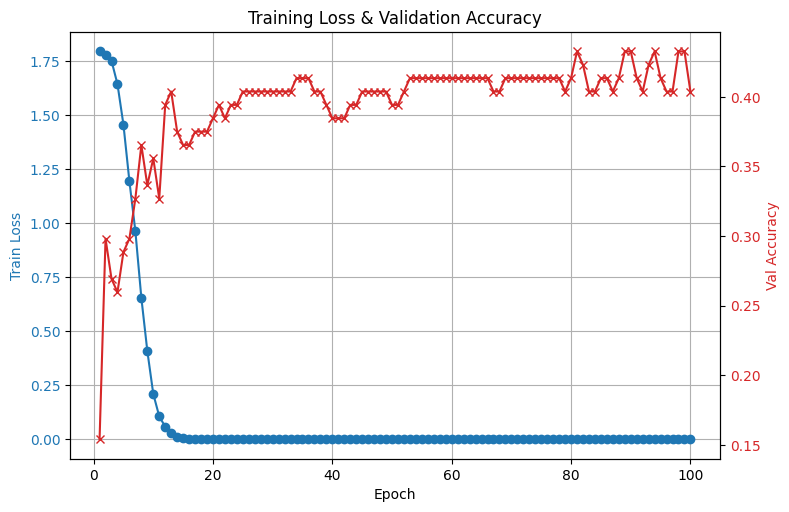

In [106]:
plot_training(train_losses, val_accuracies)

## Model Testing

In [ ]:
# create id2label mapping for output interpretation
id2label = {idx: label for idx, label in enumerate(DEFAULT_LABEL_ORDER)}

def predict_emotion(text, model, processor, word2id, id2label, device, max_len=50):
    model.eval() # set model to evaluation mode
    with torch.no_grad():
        # preprocess the input text
        tokens = processor.process(text, remove_stopwords_flag=True)

        # convert tokens to numerical sequence, handle unknown words and truncate
        seq = [word2id.get(w, 1) for w in tokens][:max_len]

        # pad the sequence to max_len
        padded_seq = seq + [0] * (max_len - len(seq))

        # convert to tensor and add batch dimension
        input_tensor = torch.tensor([padded_seq], dtype=torch.long).to(device)

        # get model output (logits)
        output = model(input_tensor)

        # get predicted class (index with highest logit)
        _, predicted_idx = torch.max(output, 1)

        # map index to label
        predicted_label = id2label[predicted_idx.item()]

        return predicted_label

In [ ]:
# example usage: prompting the user for input
while True:
    sentence = input("Enter a sentence (or 'quit' to exit): ")
    if sentence.lower() == 'quit':
        break
    if sentence:
        predicted = predict_emotion(sentence, model, processor, word2id, id2label, device)
        print(f"The sentence '{sentence}' is predicted to be: {predicted}")
        print()
    else:
        print("Please enter a sentence.")

Enter a sentence (or 'quit' to exit): ချစ်စရာလေးပါလား
The sentence 'ချစ်စရာလေးပါလား' is predicted to be: Love
Enter a sentence (or 'quit' to exit): အတော်ရွံစရာကောင်းတယ်
The sentence 'အတော်ရွံစရာကောင်းတယ်' is predicted to be: Joy
Enter a sentence (or 'quit' to exit): မုန်းလိုက်တာ
The sentence 'မုန်းလိုက်တာ' is predicted to be: Love
Enter a sentence (or 'quit' to exit): အမယ်လေး
The sentence 'အမယ်လေး' is predicted to be: Love
Enter a sentence (or 'quit' to exit): ကယ်ကြပါ
The sentence 'ကယ်ကြပါ' is predicted to be: Fear
Enter a sentence (or 'quit' to exit): ဝိုး
The sentence 'ဝိုး' is predicted to be: Surprise
Enter a sentence (or 'quit' to exit): ထူးထူးဆန်းဆန်းပါလား
The sentence 'ထူးထူးဆန်းဆန်းပါလား' is predicted to be: Surprise
Enter a sentence (or 'quit' to exit): စိတ်ညစ်တယ်
The sentence 'စိတ်ညစ်တယ်' is predicted to be: Fear
Enter a sentence (or 'quit' to exit): မပျော်ဘူး
The sentence 'မပျော်ဘူး' is predicted to be: Surprise
Enter a sentence (or 'quit' to exit): ပျော်တယ်
The sentence 'ပျ